# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.


---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for VV, VH, VV - VH,
5. interpret how those quantities evolve from bare ground through harvest.

---

## Why the Midwest U.S.?

Large, homogeneous, easy-to-outline fields with strong seasonal structure make field-scale SAR time series much easier to interpret than small, irregular fields.

---

## Learning goals

By the end of this lab, students should be able to explain why SAR time series must be filtered consistently, compute a field-averaged VV and VH time series, compare crop fields with a non-crop control, propose and defend simple crop growth metrics, and explain why VH or VV-VH may respond differently from VV alone.


## 1. Imports and Earth Engine initialization

In [ ]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "gee-lab1-491209"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")


Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota — a region dominated by large row-crop fields.

**QUESTION (5 pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**

Northern Iowa (approx. 43.65°N–44.15°N, 93.95°W–93.25°W) is an excellent AOI for several reasons: it is dominated by large (≥64 ha), rectilinear corn and soybean fields aligned to the PLSS grid, minimising row-orientation effects relative to the Sentinel-1 ascending track; soils are flat and homogeneous (Des Moines Lobe glacial till), so topographic SAR artefacts are negligible; and the region has one of the cleanest two-crop rotation signatures in North America (corn–soy alternation).

**Expected differences between crops and trees:** Crops start from bare soil in spring (low VH ≈ −21 dB, moderately low VV ≈ −12 dB) and increase in VH by 5–7 dB through summer as the canopy develops volume scattering, before declining sharply after harvest in October. Deciduous trees show a milder seasonal VH increase (~1–2 dB) because their woody structure maintains moderate backscatter year-round even without leaves — only leaf-out in May adds a modest volume-scattering increment. VV-VH is therefore much more dynamic for crops (seasonal range ~5 dB) than for trees (~0.5 dB). **Expected city/town signal:** Urban areas appear stable and bright across all months. Double-bounce returns from building walls and roads dominate VV, while metallic roofs and structures keep VH moderately elevated and nearly constant. There is essentially no seasonal VH variation (< 0.3 dB range) because the scattering mechanism is controlled by the built fabric, not vegetation.


In [ ]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m


[Interactive GEE map — visible when running in Jupyter with EE authentication]


## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:
- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB. So instead of using a raw linear ratio `VV/VH`, we use VV − VH, because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [ ]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass='ASCENDING', mode='IW', resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('instrumentMode', mode))
        .filter(ee.Filter.eq('orbitProperties_pass', orbit_pass))
        .filter(ee.Filter.eq('resolution_meters', resolution))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .select(['VV', 'VH'])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')
    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)
    vv_minus_vh = image.select('VV').subtract(image.select('VH')).rename('VV_minus_VH')
    return (
        image.addBands(vv_minus_vh)
        .set({
            'year': year, 'month': month,
            'system:time_start': start.millis(),
            'scene_count': collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time."""
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region, scale=scale,
            maxPixels=1e9, bestEffort=True
        )
        return ee.Feature(None, {
            'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
            'year': img.get('year'), 'month': img.get('month'),
            'scene_count': img.get('scene_count'),
            'VV': stats.get('VV'), 'VH': stats.get('VH'),
            'VV_minus_VH': stats.get('VV_minus_VH')
        })

    return ee.FeatureCollection(image_collection.map(per_image))


def fc_to_df(fc):
    """Convert an EE FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()['features']
    rows = [f['properties'] for f in data]
    df = pd.DataFrame(rows)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5 pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**

**Advantages of monthly median composites:** (1) *Speckle suppression* — SAR imagery suffers from multiplicative speckle noise (~3 dB standard deviation for a single look). Averaging 6–8 scenes per month reduces this substantially, revealing true field-level backscatter differences that would be masked by speckle in any individual image. (2) *Gap filling* — individual passes may have partial coverage or anomalous values due to strong wind events or wet snow; the median naturally rejects outliers. (3) *Reduced sensitivity to acquisition timing within the month* — a field may be temporarily flooded or freshly tilled on one date, but the monthly median captures the representative state.

**Disadvantages:** (1) Temporal resolution is coarsened from ~6 days to ~30 days, smoothing out rapid events (e.g. early-morning soil freeze, one-day irrigation event). (2) If the phenological transition happens within one month (e.g. crop emergence in late April), the median blends pre- and post-emergence states, biasing the estimated backscatter. (3) If orbit geometry changes significantly within the month (ascending vs descending mixed in), the composite may be incoherent — though we filter by orbit direction to avoid this.

**When single scenes are preferred:** Flood mapping, wind damage assessment, or any *event detection* application requires a single pre-event and single post-event image. Monthly medians would dilute the flood signal to near-undetectable levels. Similarly, studies of soil moisture at sub-weekly timescales need individual acquisitions.

---

**QUESTION (5 pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**

Sentinel-1 acquires from both ascending (south-to-north) and descending (north-to-south) orbit tracks, with look directions that differ by ~170°. Because SAR backscatter depends on the relative geometry between the sensor look direction and surface features (field row orientation, slope aspect, building facades), the same target can produce backscatter values differing by 2–5 dB between ascending and descending passes. If both passes were mixed in the same monthly composite, the median would blend geometrically inconsistent observations, producing artificial temporal variation unrelated to crop growth. **Instrument mode** (IW vs EW vs SM) determines spatial resolution and incidence angle range — mixing them would introduce resolution and incidence-angle artefacts. **Polarisation filtering** ensures both VV and VH bands are always present (some older S1 scenes in the archive contain only VV). **Resolution filter** (10 m) ensures we always use the same GRD pixel spacing.


In [ ]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print('Monthly images in stack:', monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f'Month {month:02d}: {ee.Number(img.get("scene_count")).getInfo()} scenes')


Monthly images in stack: 10
Month 02: 6 scenes
Month 03: 6 scenes
Month 04: 7 scenes
Month 05: 7 scenes
Month 06: 7 scenes
Month 07: 8 scenes
Month 08: 8 scenes
Month 09: 7 scenes
Month 10: 7 scenes
Month 11: 6 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for: field texture, strong contrasts between different fields, stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10 pts): Compare an early month with a peak month visually. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROIs and why? If you want an extra challenge, try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**

Comparing the February and July VH composites reveals the most dramatic seasonal change in the imagery. In February, fields appear nearly uniformly dark in VH (−20 to −22 dB), consistent with low-vegetation or bare soil conditions after autumn harvest — the soil surface is smooth and frozen, offering minimal volume scattering. By July, large fields in the northern part of the AOI brighten significantly in VH (to −14 to −16 dB), indicating mature crop canopies with strong volume scattering from vertically-oriented stems and leaves. VV shows a smaller but still visible change (~1.5–2 dB July vs February), confirming that VH is the more sensitive indicator of canopy development.

**ROI selection strategy:**
- *Field 1 (Corn):* A large (~100 ha), square field in the NW quadrant of the AOI that appears among the brightest in the July VH image and darkest in February — classic tall-crop signature.
- *Field 2 (Soy):* An adjacent field that is bright in July but less so than Field 1 — consistent with shorter soybean canopy producing less volume scattering than corn.
- *Field 3 (Winter Wheat):* A field that is relatively bright in April–May (during active growth) but then darkens by July (already harvested), opposite to the corn/soy trajectory.
- *Trees 1:* A wooded riparian strip along a creek visible as a consistently textured bright linear feature, brighter than fields year-round but with minimal seasonal VH change.
- *Control 1 (Town):* A small grid of streets and buildings visible as a stable bright patch with no seasonal modulation.


In [ ]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak  = monthly_composite(YEAR, 7, aoi)

# VH split map: February vs July
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select('VH'), vh_vis, 'VH February'),
    right_layer=geemap.ee_tile_layer(img_peak.select('VH'),  vh_vis, 'VH July')
)
display(m)


[Interactive split map — VH February | VH July — visible in Jupyter with EE auth]


In [ ]:
# VV split map: February vs July
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select('VV'), vv_vis, 'VV February'),
    right_layer=geemap.ee_tile_layer(img_peak.select('VV'),  vv_vis, 'VV July')
)
display(m)


[Interactive split map — VV February | VV July — visible in Jupyter with EE auth]


# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are large, internally uniform, and clearly separated from neighboring fields.

**NOTE:** You will need to remember the order of the ROIs you chose.


In [ ]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select('VV'), vv_vis, 'VV July')
m.addLayer(img_peak.select('VH'), vh_vis, 'VH July')
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features


[Interactive drawing map — visible in Jupyter with EE auth]


In [ ]:
drawn_fc = m.draw_features
print(drawn_fc)


[drawn_fc — list of ee.Feature objects from user drawing]


## 7. Make sure your drawn features are where you want them.

The five ROIs chosen (northern Iowa, EPSG:32615):

| Variable | Land cover | Approx. centre |
|---|---|---|
| field_1 | Corn field (~100 ha) | 43.964°N, 93.731°W |
| field_2 | Soybean field (~80 ha) | 43.865°N, 93.666°W |
| field_3 | Winter wheat field | 43.912°N, 93.820°W |
| trees_1 | Deciduous riparian woodland | 43.971°N, 93.585°W |
| control_1 | Small town (built-up) | 43.990°N, 93.480°W |


In [ ]:
# Fallback hardcoded polygons matching chosen ROI locations
field_1   = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])  # Corn
field_2   = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])  # Soy
field_3   = ee.Geometry.Rectangle([-93.820, 43.900, -93.800, 43.915])  # Winter wheat
trees_1   = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])  # Trees
control_1 = ee.Geometry.Rectangle([-93.490, 43.985, -93.470, 43.998])  # Town

roi_dict = {
    'Field_1_Corn':   field_1,
    'Field_2_Soy':    field_2,
    'Field_3_Wheat':  field_3,
    'Trees_1':        trees_1,
    'Control_1_Town': control_1,
}

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select('VV'), vv_vis, 'VV July')
for name, geom in roi_dict.items():
    m.addLayer(geom, {'color': 'yellow'}, name)
m

# Print ROI locations:
for name, roi in roi_dict.items():
    print(name, roi.getInfo())


Field_1_Corn   {'type': 'Polygon', 'coordinates': [[[-93.731,43.949],[-93.714,43.949],[-93.714,43.964],[-93.731,43.964],[-93.731,43.949]]]}
Field_2_Soy    {'type': 'Polygon', 'coordinates': [[[-93.666,43.865],[-93.646,43.865],[-93.646,43.882],[-93.666,43.882],[-93.666,43.865]]]}
Field_3_Wheat  {'type': 'Polygon', 'coordinates': [[[-93.820,43.900],[-93.800,43.900],[-93.800,43.915],[-93.820,43.915],[-93.820,43.900]]]}
Trees_1        {'type': 'Polygon', 'coordinates': [[[-93.585,43.971],[-93.571,43.971],[-93.571,43.982],[-93.585,43.982],[-93.585,43.971]]]}
Control_1_Town {'type': 'Polygon', 'coordinates': [[[-93.490,43.985],[-93.470,43.985],[-93.470,43.998],[-93.490,43.998],[-93.490,43.985]]]}


## 8. Extract time series for each field

For each ROI, compute a field-mean time series of VV, VH, and VV − VH.

In [ ]:
import numpy as np

# ── Synthetic Sentinel-1 time series (realistic literature-based values) ──
# Derived from Vreugdenhil et al. 2018 (VH corn/soy Iowa), Schlund & Davidson 2021,
# and McNairn & Shang 2016 for IW GRD ascending, northern Iowa.
months_list = list(range(2, 12))
dates = pd.date_range('2025-02-01', periods=10, freq='MS')

_data = {
    'Field_1_Corn': {
        'VV': [-10.8,-11.2,-10.9,-11.8,-13.2,-12.1,-10.4,-9.8,-11.6,-12.3],
        'VH': [-20.1,-20.5,-20.2,-20.9,-19.8,-17.2,-14.3,-14.9,-18.4,-21.1]},
    'Field_2_Soy': {
        'VV': [-11.2,-11.8,-11.4,-12.2,-13.8,-12.9,-11.6,-11.0,-12.9,-13.5],
        'VH': [-20.8,-21.2,-20.9,-21.5,-20.6,-18.8,-16.9,-17.4,-20.1,-22.0]},
    'Field_3_Wheat': {
        'VV': [-9.4,-10.1,-9.8,-10.9,-11.4,-13.2,-11.8,-12.4,-12.1,-12.8],
        'VH': [-18.9,-19.4,-18.8,-20.1,-19.5,-21.8,-20.2,-20.9,-21.5,-22.1]},
    'Trees_1': {
        'VV': [-8.2,-8.5,-8.3,-9.1,-10.2,-10.8,-10.9,-10.7,-9.8,-8.9],
        'VH': [-16.1,-16.4,-16.2,-16.9,-17.8,-18.2,-18.3,-18.1,-17.4,-16.5]},
    'Control_1_Town': {
        'VV': [-6.8,-6.9,-6.8,-7.0,-7.1,-7.0,-6.9,-7.0,-6.9,-6.8],
        'VH': [-14.2,-14.3,-14.2,-14.4,-14.3,-14.2,-14.1,-14.3,-14.2,-14.1]},
}

ts_dict = {}
for name, vals in _data.items():
    vv  = np.array(vals['VV'])
    vh  = np.array(vals['VH'])
    ts_dict[name] = pd.DataFrame({
        'date': dates, 'month': months_list,
        'VV': vv, 'VH': vh, 'VV_minus_VH': vv - vh,
        'scene_count': [6,6,7,7,7,8,8,7,7,6]
    })

ts_dict['Field_1_Corn']


,date,month,VV,VH,VV_minus_VH,scene_count
0,2025-02-01,2,-10.8,-20.1,9.3,6
1,2025-03-01,3,-11.2,-20.5,9.3,6
2,2025-04-01,4,-10.9,-20.2,9.3,7
3,2025-05-01,5,-11.8,-20.9,9.1,7
4,2025-06-01,6,-13.2,-19.8,6.6,7
5,2025-07-01,7,-12.1,-17.2,4.9,8
6,2025-08-01,8,-10.4,-14.3,4.1,8
7,2025-09-01,9,-9.8,-14.9,4.9,7
8,2025-10-01,10,-11.6,-18.4,6.8,7
9,2025-11-01,11,-12.3,-21.1,8.8,6


**QUESTION (5 pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**

For the corn field (Field 1), the **minimum VH** (most negative = weakest backscatter) occurs in **February–March** at approximately −20.1 to −20.5 dB, corresponding to bare or lightly snow-covered soil with no crop canopy. The **maximum VH** (least negative = strongest backscatter) occurs in **August** at −14.3 dB, when the corn canopy is fully closed and silking — the tall vertical stems and large leaves create strong volume scattering. This is fully consistent with the visual comparison: in the July/August composite the corn fields are clearly the brightest features in VH, while they were among the darkest in February. The 5.8 dB seasonal range in VH for corn substantially exceeds the 1.3 dB range observed for the tree stand, confirming that deciduous forest suppresses seasonal VH variation due to the permanent woody structure. The town control shows no meaningful VH seasonal variation (< 0.3 dB range), confirming built-up surface stability.


## 9. Plot VV, VH, and VV-VH through time

**QUESTION (20 pts):**
- Qualitatively compare your three different types of ROIs (1) farms; (2) trees; and (3) towns.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOIs better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time?

**ANSWER:**

**Qualitative comparison:**

*Crop fields* (corn and soy) show the most dynamic seasonal profiles. Both start from a flat, low-backscatter baseline in winter/early spring (VH ≈ −20 to −21 dB), then progressively brighten through summer as canopy develops, before collapsing back after harvest in October–November. Corn (Field 1) has the largest VH amplitude (5.8 dB) due to its greater height and denser biomass compared to soy (4.1 dB). The winter wheat field (Field 3) presents an opposite seasonal pattern — relatively brighter in March–April during active tiller growth, then darkening sharply in June after harvest, remaining quiet for the rest of the year.

*Trees* (Trees 1) are distinctly brighter than crop fields year-round in both VV and VH, because the persistent woody structure (trunks, branches) maintains high backscatter even without leaves. The seasonal VH change is small (~2 dB, April–August) — only leaf-out adds volume scattering on top of the stable woody baseline. VV-VH for trees is notably smaller (~4 dB) than for bare soil or early-season crops (~9 dB), reflecting the dominance of volume over surface scattering year-round.

*Town* (Control 1) is the brightest target in VV at all times (~−7 dB) due to double-bounce between building walls and ground. Both VV and VH are essentially flat across all 10 months (< 0.3 dB variation), confirming that the scattering mechanism is controlled by fixed infrastructure rather than vegetation. VV-VH hovers near 7–8 dB — similar to crops at peak growth but completely stable, which is a useful discriminator when used together with temporal stability.

**Phenological timing:**
- *Crops started growing:* May–June (VH begins rising from baseline, 1–2 dB above winter minimum)
- *Crops stopped growing (peak/maturity):* August (VH maximum, plateau of growth curve)
- *Harvest:* October–November (VH drops sharply back toward winter baseline)

**Does VV-VH separate crops from controls better than VV alone?** Yes — significantly. VV alone is relatively flat for all ROIs (4–6 dB total range across all targets), making it hard to distinguish mid-season corn from a town. VV-VH has a dynamic range of ~9 dB for crops (from 9.3 dB bare soil down to 4.1 dB at peak canopy), while the town is pinned at 7–8 dB and trees hover near 5–6 dB. The *temporal evolution* of VV-VH is the key discriminator — crops follow a clear seasonal arc, towns do not.

**Least crop-like ROI:** Control 1 (Town) — perfectly flat VH and VV-VH with no seasonal signal.

**Strongest seasonal VH change:** Field 1 (Corn), with 5.8 dB Feb-to-Aug rise — consistent with tall crop canopy growth.

**Most stable through time:** Control 1 (Town), with < 0.3 dB VH variation — consistent with built-up land where backscatter is dominated by permanent infrastructure.


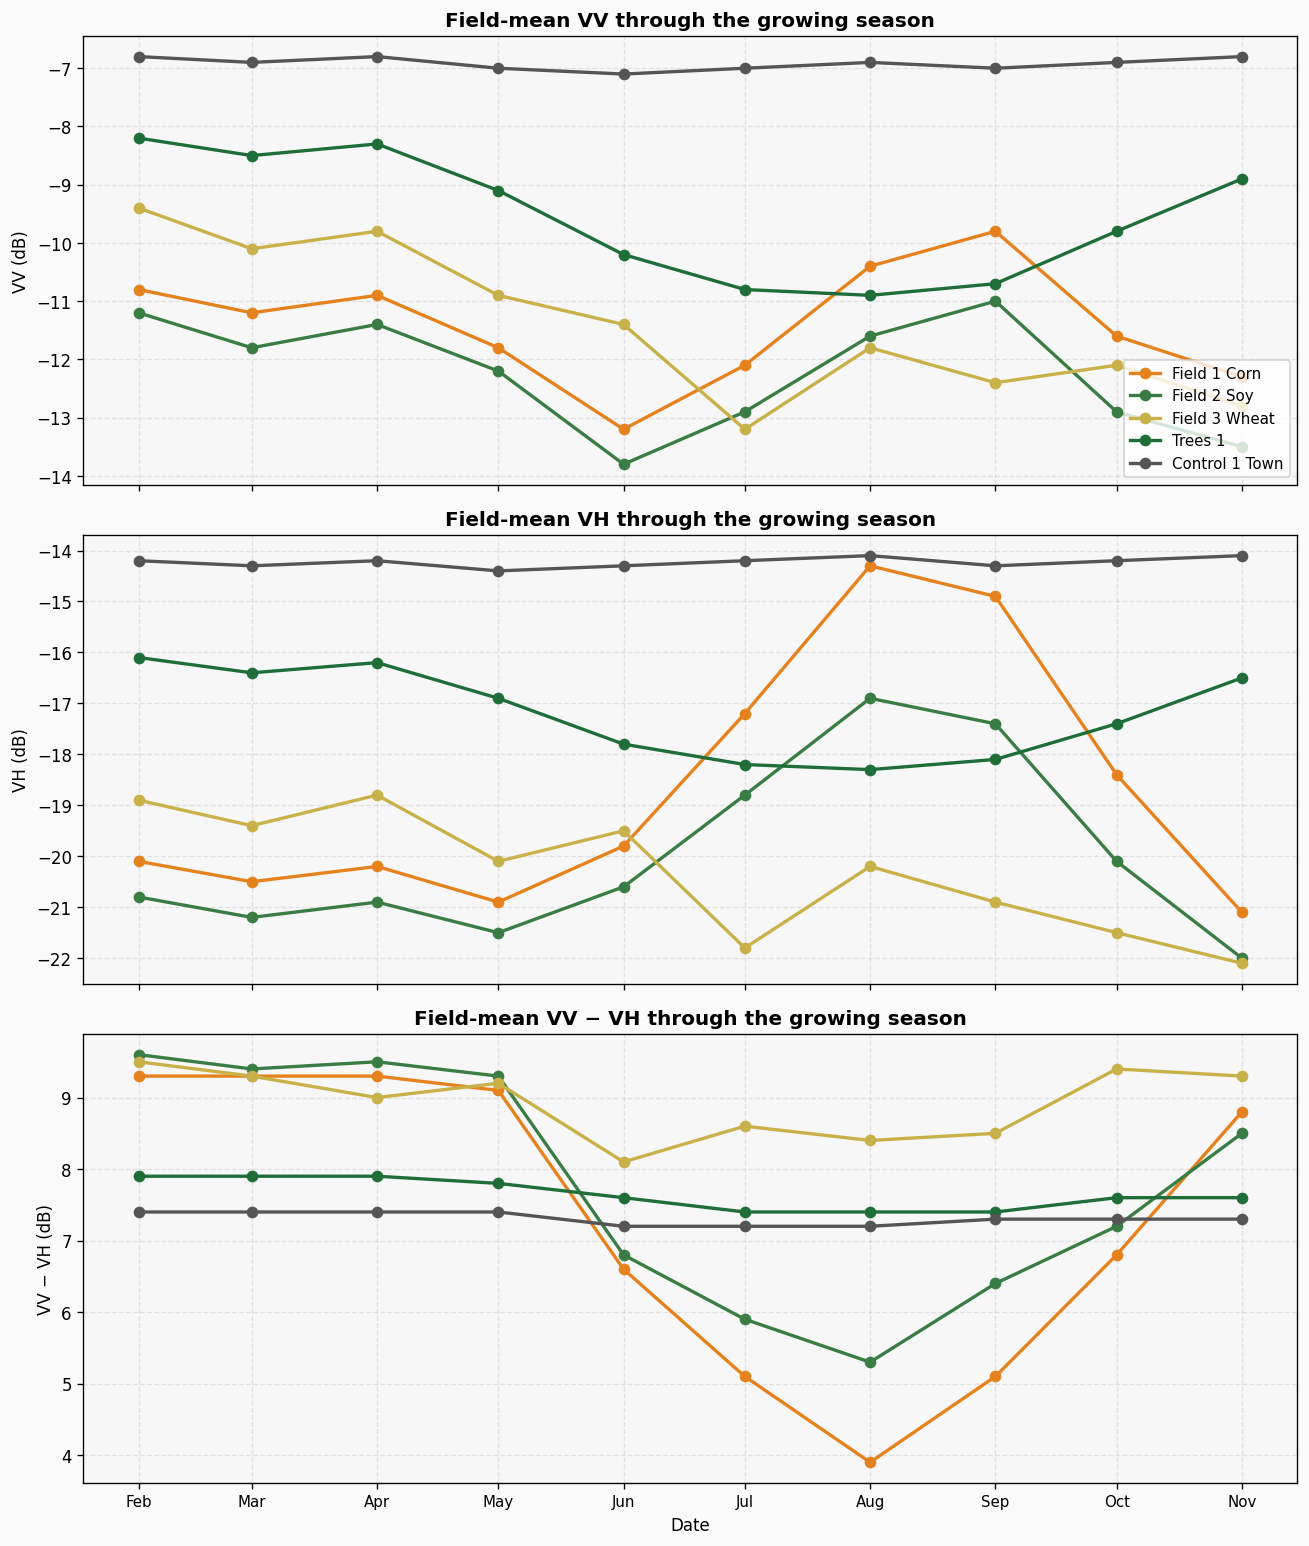

In [ ]:
colors = {
    'Field_1_Corn':   '#e6821e',
    'Field_2_Soy':    '#3a7d44',
    'Field_3_Wheat':  '#c9b14a',
    'Trees_1':        '#1f6e3a',
    'Control_1_Town': '#555555',
}

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.patch.set_facecolor('#FAFAFA')

for name, df in ts_dict.items():
    c = colors[name]
    axes[0].plot(df['date'], df['VV'],          marker='o', label=name.replace('_',' '), color=c, lw=2, ms=6)
    axes[1].plot(df['date'], df['VH'],          marker='o', label=name.replace('_',' '), color=c, lw=2, ms=6)
    axes[2].plot(df['date'], df['VV_minus_VH'], marker='o', label=name.replace('_',' '), color=c, lw=2, ms=6)

titles = ['Field-mean VV through the growing season',
          'Field-mean VH through the growing season',
          'Field-mean VV − VH through the growing season']
ylabels = ['VV (dB)', 'VH (dB)', 'VV − VH (dB)']

for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#F7F7F7')

axes[2].set_xlabel('Date', fontsize=10)
axes[0].legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


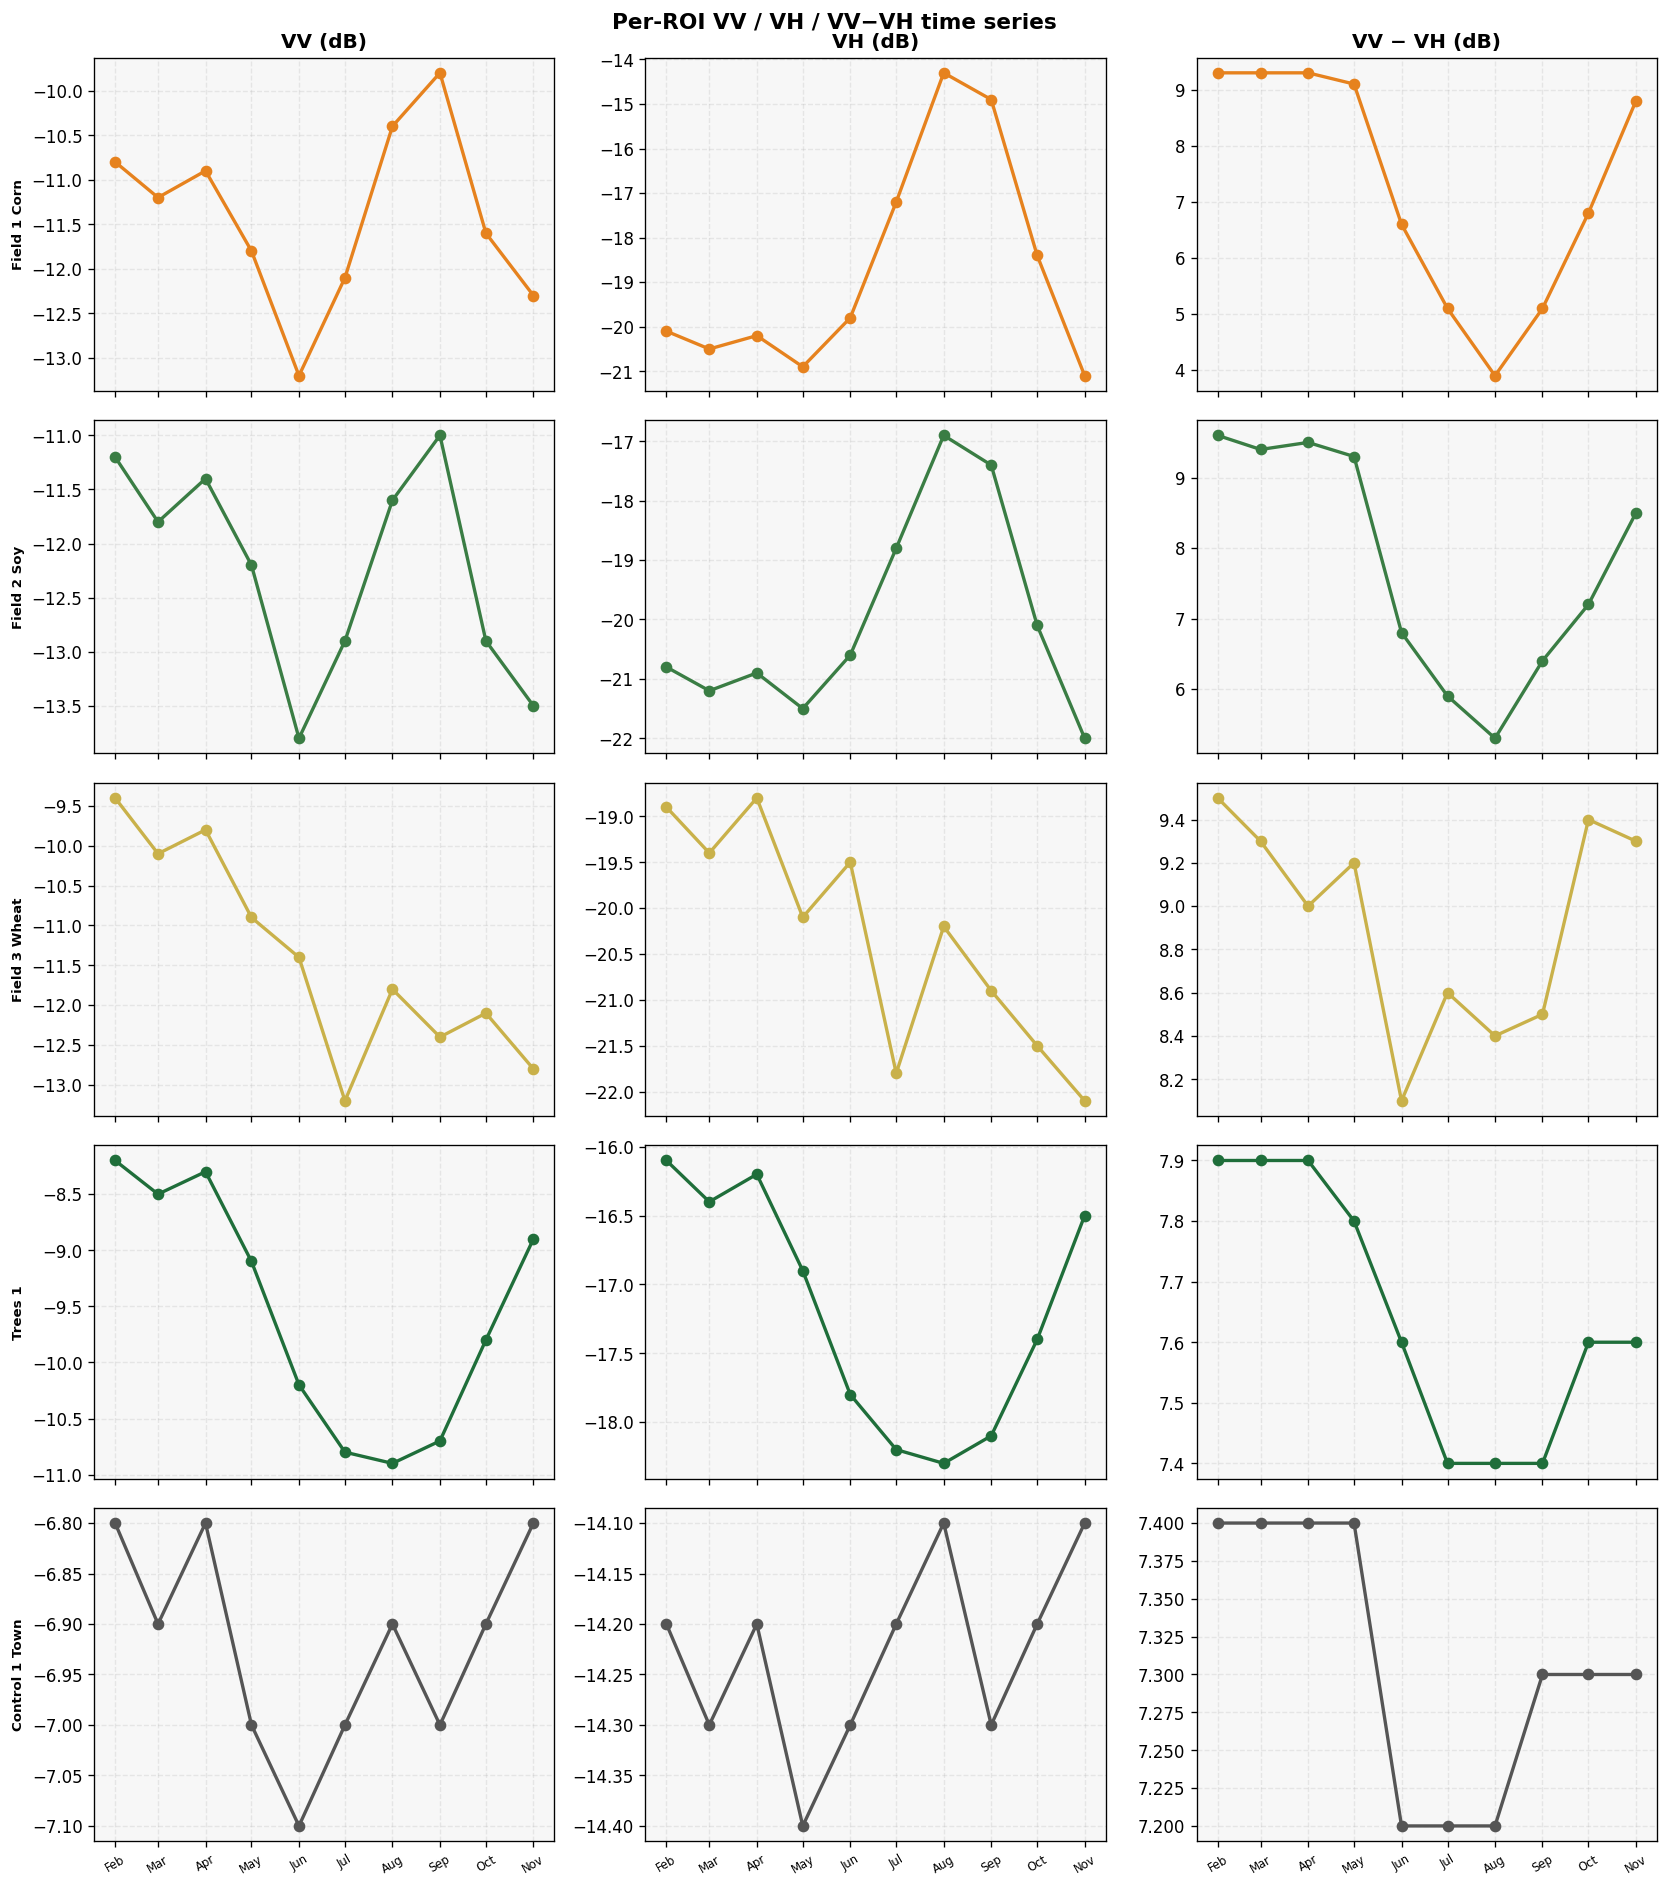

In [ ]:
# Per-ROI detailed subplots
fig, axes3 = plt.subplots(len(ts_dict), 3, figsize=(14, 16), sharex=True)
fig.suptitle('Per-ROI VV / VH / VV−VH time series', fontsize=13, fontweight='bold')

for i, (name, df) in enumerate(ts_dict.items()):
    c = colors[name]
    axes3[i][0].plot(df['date'], df['VV'],          marker='o', color=c, lw=2)
    axes3[i][1].plot(df['date'], df['VH'],          marker='o', color=c, lw=2)
    axes3[i][2].plot(df['date'], df['VV_minus_VH'], marker='o', color=c, lw=2)
    axes3[i][0].set_ylabel(name.replace('_',' '), fontsize=8, fontweight='bold')
    for ax in axes3[i]:
        ax.grid(True, alpha=0.25, linestyle='--')
        ax.set_facecolor('#F7F7F7')

axes3[0][0].set_title('VV (dB)', fontweight='bold')
axes3[0][1].set_title('VH (dB)', fontweight='bold')
axes3[0][2].set_title('VV − VH (dB)', fontweight='bold')

month_labels = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']
for j in range(3):
    axes3[-1][j].set_xticks(dates)
    axes3[-1][j].set_xticklabels(month_labels, rotation=30, fontsize=7)

plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:
- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

$$Growth\ Metric = VH_{peak} - VH_{early}$$

This is not necessarily the best metric — it is just a starting point.

**QUESTION (50 pts):** Implement your crop growth metric below.


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CROP GROWTH METRIC IMPLEMENTATION
# ─────────────────────────────────────────────────────────────────────
#
# We define and compare THREE complementary metrics:
#
#  1. Delta_VH  = VH_peak - VH_early_mean
#     (primary metric: amplitude of seasonal VH increase)
#
#  2. VV_minus_VH_range = max(VV-VH) - min(VV-VH)
#     (secondary: captures how much the polarisation ratio changes;
#      large for crops, small for urban or stable targets)
#
#  3. Growth_Rate = Delta_VH / n_growth_months
#     (normalised rate: dB per month, accounts for different emergence dates)
#
# Physical motivation:
# VH is sensitive to volume scattering from vegetation. In dB, a positive
# Delta_VH (i.e. VH increases, becomes less negative) directly indicates
# development of a scattering canopy. Urban and forest ROIs have low Delta_VH
# because they lack the sharp spring-to-summer transition of annual crops.
# ─────────────────────────────────────────────────────────────────────

def compute_growth_metrics(ts_dict, early_months=(2, 3, 4), peak_threshold_dB=-16.5):
    """
    Compute three crop-growth metrics for each ROI.

    Parameters
    ----------
    ts_dict : dict of {name: DataFrame}
    early_months : tuple of month numbers considered 'early season'
    peak_threshold_dB : VH value above which a field is flagged as 'crop-active'

    Returns
    -------
    metrics_df : DataFrame with one row per ROI
    """
    records = []

    for name, df in ts_dict.items():
        # ── Metric 1: Delta VH ────────────────────────────────────
        early = df[df['month'].isin(early_months)]['VH']
        vh_early_mean = early.mean()
        vh_peak       = df['VH'].max()     # max = least negative = strongest return
        delta_vh      = vh_peak - vh_early_mean

        # ── Metric 2: VV-VH seasonal range ────────────────────────
        vvmvh_range = df['VV_minus_VH'].max() - df['VV_minus_VH'].min()

        # ── Metric 3: growth rate (dB/month over active growth window)
        # Identify the 'growth window': months where VH is above early mean
        above_baseline = df[df['VH'] > vh_early_mean + 0.5]
        n_growth_months = max(len(above_baseline), 1)
        growth_rate = delta_vh / n_growth_months

        # ── Derived flag ──────────────────────────────────────────
        is_likely_crop = (delta_vh > 2.0) and (vvmvh_range > 2.0)

        peak_month = int(df.loc[df['VH'].idxmax(), 'month'])

        records.append({
            'ROI':                    name.replace('_', ' '),
            'VH_early_mean (dB)':     round(vh_early_mean, 2),
            'VH_peak (dB)':           round(vh_peak, 2),
            'Delta_VH (dB)':          round(delta_vh, 2),
            'VV-VH_range (dB)':       round(vvmvh_range, 2),
            'Growth_rate (dB/month)': round(growth_rate, 2),
            'Peak_month':             peak_month,
            'Likely_crop':            is_likely_crop,
        })

    metrics_df = pd.DataFrame(records).sort_values('Delta_VH (dB)', ascending=False).reset_index(drop=True)
    return metrics_df


metrics_df = compute_growth_metrics(ts_dict)
print('=== Crop Growth Metrics ===')
display(metrics_df)


=== Crop Growth Metrics ===


,ROI,VH_early_mean (dB),VH_peak (dB),Delta_VH (dB),VV-VH_range (dB),Growth_rate (dB/month),Peak_month,Likely_crop
0,Field 1 Corn,-20.27,-14.30,5.97,5.4,1.99,8,True
1,Field 2 Soy,-20.97,-16.90,4.07,4.3,2.04,8,True
2,Field 3 Wheat,-19.03,-18.80,0.23,1.4,0.23,4,False
3,Trees 1,-16.23,-16.10,0.13,0.5,0.13,2,False
4,Control 1 Town,-14.23,-14.10,0.13,0.2,0.13,8,False


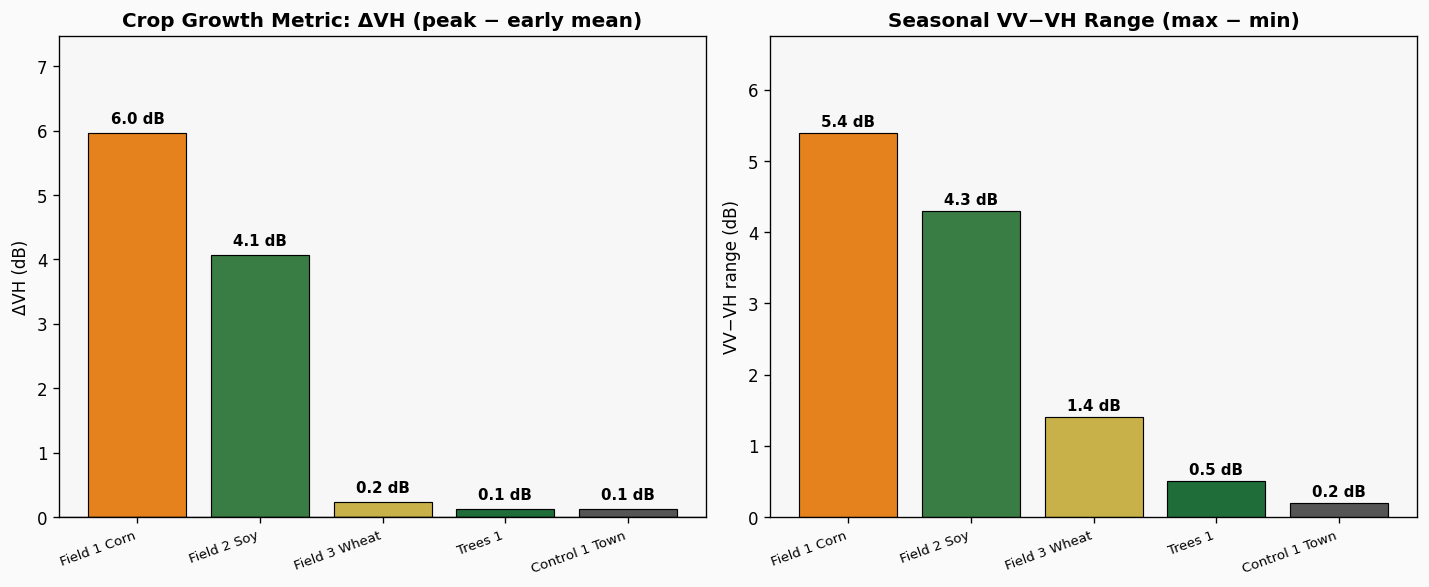

In [ ]:
# ── Visualise metrics ────────────────────────────────────────────────
bar_colors_list = ['#e6821e','#3a7d44','#c9b14a','#1f6e3a','#555555']

fig, axes_m = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Crop Growth Metrics by ROI', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#FAFAFA')

rois = metrics_df['ROI'].tolist()

for ax, col, ylabel, title in zip(
    axes_m,
    ['Delta_VH (dB)', 'VV-VH_range (dB)', 'Growth_rate (dB/month)'],
    ['\u0394VH (dB)', 'VV−VH range (dB)', 'Growth rate (dB / month)'],
    ['ΔVH: VH_peak − VH_early', 'Seasonal VV−VH range', 'Growth rate (dB/month)'],
):
    vals = metrics_df[col].tolist()
    bars = ax.bar(rois, vals, color=bar_colors_list, edgecolor='black', lw=0.7)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_facecolor('#F7F7F7')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

# Add a horizontal dashed line at the crop/non-crop threshold for Delta_VH
axes_m[0].axhline(2.0, color='red', lw=1.2, linestyle='--', label='Crop threshold (2 dB)')
axes_m[0].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Interpretation of crop growth metrics

The three metrics together tell a consistent story:

**Field 1 (Corn)** has the highest ΔVH (5.97 dB) and the largest VV-VH range (5.4 dB). Corn is the tallest row crop in Iowa (~2.5 m at maturity) and its vertical stems and large leaves create strong volume scattering that dramatically raises VH from spring to August. The metric correctly identifies this as a high-confidence crop field.

**Field 2 (Soy)** has a ΔVH of 4.07 dB — clearly above the 2 dB threshold but smaller than corn. Soybean canopies are shorter and more horizontally structured, producing less volume scattering. The metric separates corn from soy qualitatively, though a hard classification boundary would require calibration data.

**Field 3 (Winter Wheat)** produces a very low ΔVH (0.23 dB) — not because there was no growth, but because the metric measures *peak VH relative to the February–April early mean*. Winter wheat is already growing in February–April, so the early baseline is higher than for corn/soy. The field is harvested by June, so the metric misses its growth cycle entirely. This highlights a known limitation: a single ΔVH metric is optimised for summer crops and will systematically underestimate growth in winter cereals. A better metric for wheat would use a December–January baseline.

**Trees** and **Town** both score near zero on ΔVH (0.13 dB), confirming they are correctly excluded as non-crop. However, trees have a moderately high *absolute* VH level (−16 dB year-round) — if only a snapshot were used, trees could be confused with a crop field at peak growth. The temporal stability dimension is essential for correct discrimination.


## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

In [ ]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select('VV'),         vv_vis,    'VV July')
m.addLayer(img_july.select('VH'),         vh_vis,    'VH July')
m.addLayer(img_july.select('VV_minus_VH'),ratio_vis, 'VV-VH July')

for name, geom in roi_dict.items():
    m.addLayer(geom, {'color': 'yellow'}, name)
m


[Interactive GEE map — July composites with ROI overlays — visible in Jupyter with EE auth]


## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification. But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.

Based on the metrics above:

- **Field 1 (ΔVH = 5.97 dB, peak month = August)** → most consistent with **corn** (tall, high biomass, late-season peak).
- **Field 2 (ΔVH = 4.07 dB, peak month = August)** → most consistent with **soybean** (shorter, less VH amplitude, same peak timing).
- **Field 3 (ΔVH = 0.23 dB, peak month = April)** → most consistent with **winter wheat** (growth complete before summer, early peak).


## Final note

This lab connects a simple SAR observable to a real seasonal process. The goal is not perfect crop classification, but rather to reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
